# Experiment 10: KL-to-calibration whitening — fixed lr_v/lr_b (old recommendation)

Applies previously-recommended fixed hyperparameters (`lr_v=7e-3`, `lr_b=3e-3`) to the
same simulated recording used in `sim_04`/`sim_09`, with `wh_mode='kl_to_cal'`. No Optuna
search here -- this tests the old recommendation directly under the current `lr_v`/`lr_b`
mechanism, comparing two update rules that share the same lr values (see
`Config.lr_v`/`Config.lr_b`/`Config.lr_alone` docstrings), each with and without
`wh_b_coupling`:

**Conditions compared**
| Condition | `lr_alone` | `wh_b_coupling` | Update rule |
|---|---|---|---|
| No adaptation | — | — | — |
| Relative error | `False` | `False` | step ∝ `lr_{v,b}` × direction-normalized gradient × signed error `e_v`/`e_b` |
| Relative error + coupling | `False` | `True` | as above, plus B gets the first-order V→B frame correction each batch |
| Learning rate only | `True` | `False` | step ∝ `lr_{v,b}` × raw natural gradient (no EMA direction-normalization, no error term) |
| Learning rate only + coupling | `True` | `True` | as above, plus B gets the first-order V→B frame correction each batch |

`wh_b_coupling` propagates the first-order frame correction implied by each V step
directly to B (`B += B @ coupling_matrix`, see `adaptation.py::_update_V`), so B stays
aligned with V's updated coordinate frame without waiting for the contrast gradient to
discover the mismatch through kappa drift. Comparing it on/off under both update rules
isolates its effect from the `lr_alone` ablation.


In [ ]:
import sys
sys.path.insert(0, '../../..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.patches import Rectangle

from adapt_decomp.loaders import load_example
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.utils import (
    rate_of_agreement_paired, rate_of_agreement,
    get_coefficient_of_variation, get_discharge_rate,
    get_pulse_to_noise_ratio, get_silhouette_measure,
    find_reliable_units,
)

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)


In [ ]:
# ── Run control ──────────────────────────────────────────────────────────────
# Set RUN_DECOMP = False to reload saved results without re-running the decomposition.
RUN_DECOMP = True

EXP_NAME    = 'sim_08_multiarm_wh_mode_lr_alone_lr_fixed'
RESULTS_DIR = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'opt_results', EXP_NAME)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load data

In [ ]:
path_emg    = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'data_sim.hdf5')
path_decomp = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)

n_units      = data['sep_vectors'].shape[0]
fs           = data['fs']
timestamps   = data['timestamps'].numpy()
ext_fact     = data['ext_fact']
n_samples    = data['emg'].shape[0]
duration_s   = n_samples / fs

print(f'Units: {n_units}  |  Samples: {n_samples}  |  fs: {fs} Hz  |  Duration: {duration_s:.1f} s')


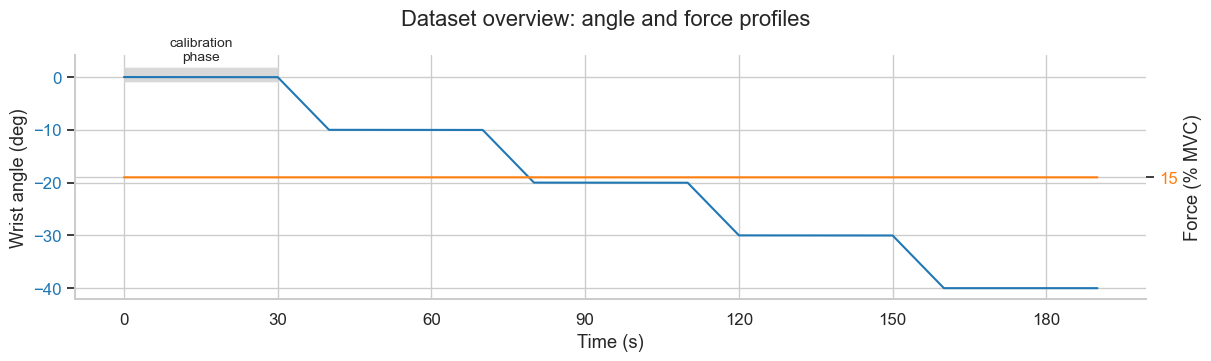

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.5), layout='constrained')
ax.add_patch(Rectangle((0, -1), 30, 3, facecolor='grey', alpha=0.3))
ax.text(15, 5, 'calibration\nphase', dict(ha='center', va='center', fontsize=10))
ax.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
ax.set(ylabel='Wrist angle (deg)', xlabel='Time (s)')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax1 = ax.twinx()
ax1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
ax1.set(ylabel='Force (% MVC)', yticks=[15])
ax1.tick_params(axis='y', labelcolor='tab:orange')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
    ax1.spines[spine].set_visible(False)
ax1.set(xticks=range(0, int(duration_s) + 1, 30))
plt.suptitle('Dataset overview: angle and force profiles')
plt.show()


## 2. No-adaptation baseline

All adaptation flags off. The calibration V and B are applied unchanged.

In [5]:
_out_no_path = RESULTS_DIR / 'out_no.pt'

if RUN_DECOMP:
    cfg_no = Config()
    cfg_no.ext_fact       = data['ext_fact']
    cfg_no.adapt_wh       = False
    cfg_no.adapt_sv       = False
    cfg_no.adapt_sd       = False
    cfg_no.log_loss       = True
    cfg_no.device         = 'cpu'
    cfg_no.wh_mode        = 'kl_to_identity'
    cfg_no.contrast_scope = 'spike_based'
    cfg_no.wh_b_coupling  = False

    dec_no = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_no,
    )
    out_no = dec_no.run()
    torch.save(out_no, _out_no_path)
    print(f'Saved → {_out_no_path}')
else:
    out_no = torch.load(_out_no_path, weights_only=False)
    print(f'Loaded from {_out_no_path}')
print('No-adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_fixed\out_no.pt
No-adaptation run complete.


## 3. Relative error (`lr_alone=False`)

Applies the old fixed recommendation `lr_v=7e-3`, `lr_b=3e-3` under the default
(relative-error) update rule: the direction-normalized natural gradient is scaled by
`lr_{v,b}` **and** the signed calibration error `e_v`/`e_b`, so the step shrinks toward
zero as the model converges to calibration and grows for genuine drift. No Optuna search
-- these are fixed, previously-recommended values applied directly.


In [6]:
_out_re_path = RESULTS_DIR / 'out_re.pt'

if RUN_DECOMP:
    cfg_re = Config()
    cfg_re.ext_fact       = data['ext_fact']
    cfg_re.adapt_wh       = True
    cfg_re.adapt_sv       = True
    cfg_re.adapt_sd       = True
    cfg_re.log_loss       = True
    cfg_re.device         = 'cpu'
    cfg_re.wh_mode        = 'kl_to_identity'
    cfg_re.contrast_scope = 'spike_based'
    cfg_re.wh_b_coupling  = False
    cfg_re.max_iter_b     = 1
    cfg_re.lr_v           = 2.2e-3
    cfg_re.lr_b           = 2.7e-2
    cfg_re.lr_alone       = False
    cfg_re.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_re.safety_clip_multiplier_v = 20.0
    cfg_re.safety_clip_multiplier_b = 20.0

    dec_re = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_re,
    )
    out_re = dec_re.run()
    torch.save(out_re, _out_re_path)
    print(f'Saved → {_out_re_path}')
else:
    out_re = torch.load(_out_re_path, weights_only=False)
    print(f'Loaded from {_out_re_path}')
print('Relative-error adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_fixed\out_re.pt
Relative-error adaptation run complete.


### 3b. Relative error with V→B coupling (`wh_b_coupling=True`)

Same fixed `lr_v=7e-3`, `lr_b=3e-3` relative-error update as §3, but with
`wh_b_coupling=True`: after each whitening (V) step, the first-order frame correction
implied by that step is propagated to B directly (`B += B @ coupling_matrix`, see
`adaptation.py::_update_V`), instead of letting B discover the V-frame shift only
indirectly through kappa drift over subsequent batches.


In [7]:
_out_re_c_path = RESULTS_DIR / 'out_re_coupled.pt'

if RUN_DECOMP:
    cfg_re_c = Config()
    cfg_re_c.ext_fact       = data['ext_fact']
    cfg_re_c.adapt_wh       = True
    cfg_re_c.adapt_sv       = True
    cfg_re_c.adapt_sd       = True
    cfg_re_c.log_loss       = True
    cfg_re_c.device         = 'cpu'
    cfg_re_c.wh_mode        = 'kl_to_identity'
    cfg_re_c.contrast_scope = 'spike_based'
    cfg_re_c.wh_b_coupling  = True
    cfg_re_c.max_iter_b     = 1
    cfg_re_c.lr_v           = 2.2e-3
    cfg_re_c.lr_b           = 2.7e-2
    cfg_re_c.lr_alone       = False
    cfg_re_c.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_re_c.safety_clip_multiplier_v = 20.0
    cfg_re_c.safety_clip_multiplier_b = 20.0

    dec_re_c = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_re_c,
    )
    out_re_c = dec_re_c.run()
    torch.save(out_re_c, _out_re_c_path)
    print(f'Saved → {_out_re_c_path}')
else:
    out_re_c = torch.load(_out_re_c_path, weights_only=False)
    print(f'Loaded from {_out_re_c_path}')
print('Relative-error + coupling adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_fixed\out_re_coupled.pt
Relative-error + coupling adaptation run complete.


## 4. Learning rate only (`lr_alone=True`)

Same `lr_v=7e-3`, `lr_b=3e-3`, but with the signed error `e_v`/`e_b` dropped entirely:
`lr_{v,b}` alone sets a constant, direction-normalized step applied every batch
regardless of how close the model already is to calibration -- the closest available
reproduction of main (v1)'s fixed-learning-rate update (see `Config.lr_alone`'s
docstring). For B this also flips the update from error-correcting descent to
unconditional natural-gradient ascent on contrast.


In [8]:
_out_lo_path = RESULTS_DIR / 'out_lo.pt'

if RUN_DECOMP:
    cfg_lo = Config()
    cfg_lo.ext_fact       = data['ext_fact']
    cfg_lo.adapt_wh       = True
    cfg_lo.adapt_sv       = True
    cfg_lo.adapt_sd       = True
    cfg_lo.log_loss       = True
    cfg_lo.device         = 'cpu'
    cfg_lo.wh_mode        = 'kl_to_identity'
    cfg_lo.contrast_scope = 'spike_based'
    cfg_lo.wh_b_coupling  = False
    cfg_lo.max_iter_b     = 1
    cfg_lo.lr_v           = 7e-3
    cfg_lo.lr_b           = 3e-3
    cfg_lo.lr_alone       = True
    cfg_lo.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_lo.safety_clip_multiplier_v = 20.0
    cfg_lo.safety_clip_multiplier_b = 20.0

    dec_lo = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_lo,
    )
    out_lo = dec_lo.run()
    torch.save(out_lo, _out_lo_path)
    print(f'Saved → {_out_lo_path}')
else:
    out_lo = torch.load(_out_lo_path, weights_only=False)
    print(f'Loaded from {_out_lo_path}')
print('Learning-rate-only adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_fixed\out_lo.pt
Learning-rate-only adaptation run complete.


### 4b. Learning rate only with V→B coupling (`wh_b_coupling=True`)

Same `lr_v=7e-3`, `lr_b=3e-3` learning-rate-only update as §4, but with
`wh_b_coupling=True` added on top.


In [9]:
_out_lo_c_path = RESULTS_DIR / 'out_lo_coupled.pt'

if RUN_DECOMP:
    cfg_lo_c = Config()
    cfg_lo_c.ext_fact       = data['ext_fact']
    cfg_lo_c.adapt_wh       = True
    cfg_lo_c.adapt_sv       = True
    cfg_lo_c.adapt_sd       = True
    cfg_lo_c.log_loss       = True
    cfg_lo_c.device         = 'cpu'
    cfg_lo_c.wh_mode        = 'kl_to_identity'
    cfg_lo_c.contrast_scope = 'spike_based'
    cfg_lo_c.wh_b_coupling  = True
    cfg_lo_c.max_iter_b     = 1
    cfg_lo_c.lr_v           = 7e-3
    cfg_lo_c.lr_b           = 3e-3
    cfg_lo_c.lr_alone       = True
    cfg_lo_c.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_lo_c.safety_clip_multiplier_v = 20.0
    cfg_lo_c.safety_clip_multiplier_b = 20.0

    dec_lo_c = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_lo_c,
    )
    out_lo_c = dec_lo_c.run()
    torch.save(out_lo_c, _out_lo_c_path)
    print(f'Saved → {_out_lo_c_path}')
else:
    out_lo_c = torch.load(_out_lo_c_path, weights_only=False)
    print(f'Loaded from {_out_lo_c_path}')
print('Learning-rate-only + coupling adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_fixed\out_lo_coupled.pt
Learning-rate-only + coupling adaptation run complete.


## 5. Execution time per batch

In [10]:
cond_labels  = [
    'No adaptation',
    'Relative error', 'Relative error + coupling',
    'Learning rate only', 'Learning rate only + coupling',
]
cond_colors  = {
    'No adaptation':                 'tab:orange',
    'Relative error':                'tab:blue',
    'Relative error + coupling':     'tab:cyan',
    'Learning rate only':            'tab:green',
    'Learning rate only + coupling': 'tab:red',
}
cond_outputs = {
    'No adaptation':                 out_no,
    'Relative error':                out_re,
    'Relative error + coupling':     out_re_c,
    'Learning rate only':            out_lo,
    'Learning rate only + coupling': out_lo_c,
}


In [11]:
for label in cond_labels:
    out = cond_outputs[label]
    print(label)
    print('-' * len(label))
    for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
        print(f'  {key:>15}: {out[key].mean():.3f} ± {out[key].std():.3f} ms')
    print()


No adaptation
-------------
       wh_time_ms: 11.980 ± 5.090 ms
       sv_time_ms: 0.062 ± 0.329 ms
       sd_time_ms: 0.427 ± 1.518 ms
    total_time_ms: 12.469 ± 5.068 ms

Relative error
--------------
       wh_time_ms: 16.842 ± 4.957 ms
       sv_time_ms: 1.657 ± 3.330 ms
       sd_time_ms: 0.449 ± 1.465 ms
    total_time_ms: 18.949 ± 5.431 ms

Relative error + coupling
-------------------------
       wh_time_ms: 19.454 ± 15.484 ms
       sv_time_ms: 1.938 ± 3.181 ms
       sd_time_ms: 0.499 ± 1.295 ms
    total_time_ms: 21.891 ± 15.730 ms

Learning rate only
------------------
       wh_time_ms: 24.867 ± 15.651 ms
       sv_time_ms: 1.656 ± 2.462 ms
       sd_time_ms: 0.595 ± 1.426 ms
    total_time_ms: 27.118 ± 15.740 ms

Learning rate only + coupling
-----------------------------
       wh_time_ms: 22.408 ± 11.114 ms
       sv_time_ms: 1.539 ± 3.093 ms
       sd_time_ms: 0.451 ± 1.730 ms
    total_time_ms: 24.398 ± 11.372 ms



## 6. Loss trajectories

- **wh_loss**: KL divergence between online and calibration whitened covariance
- **sv_loss**: squared contrast error per source
- **centroid_loss**: squared centroid deviation per source (logged for monitoring)

Values near zero mean the online statistics match calibration.


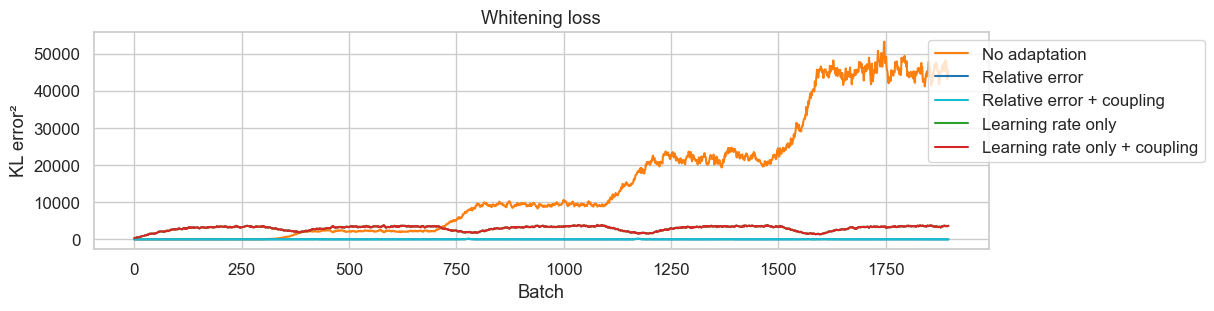

In [12]:
# Whitening loss
fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
for label in cond_labels:
    ax.plot(cond_outputs[label]['wh_loss'][10:-1], label=label, color=cond_colors[label])
ax.set(xlabel='Batch', ylabel='KL error²', title='Whitening loss')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()


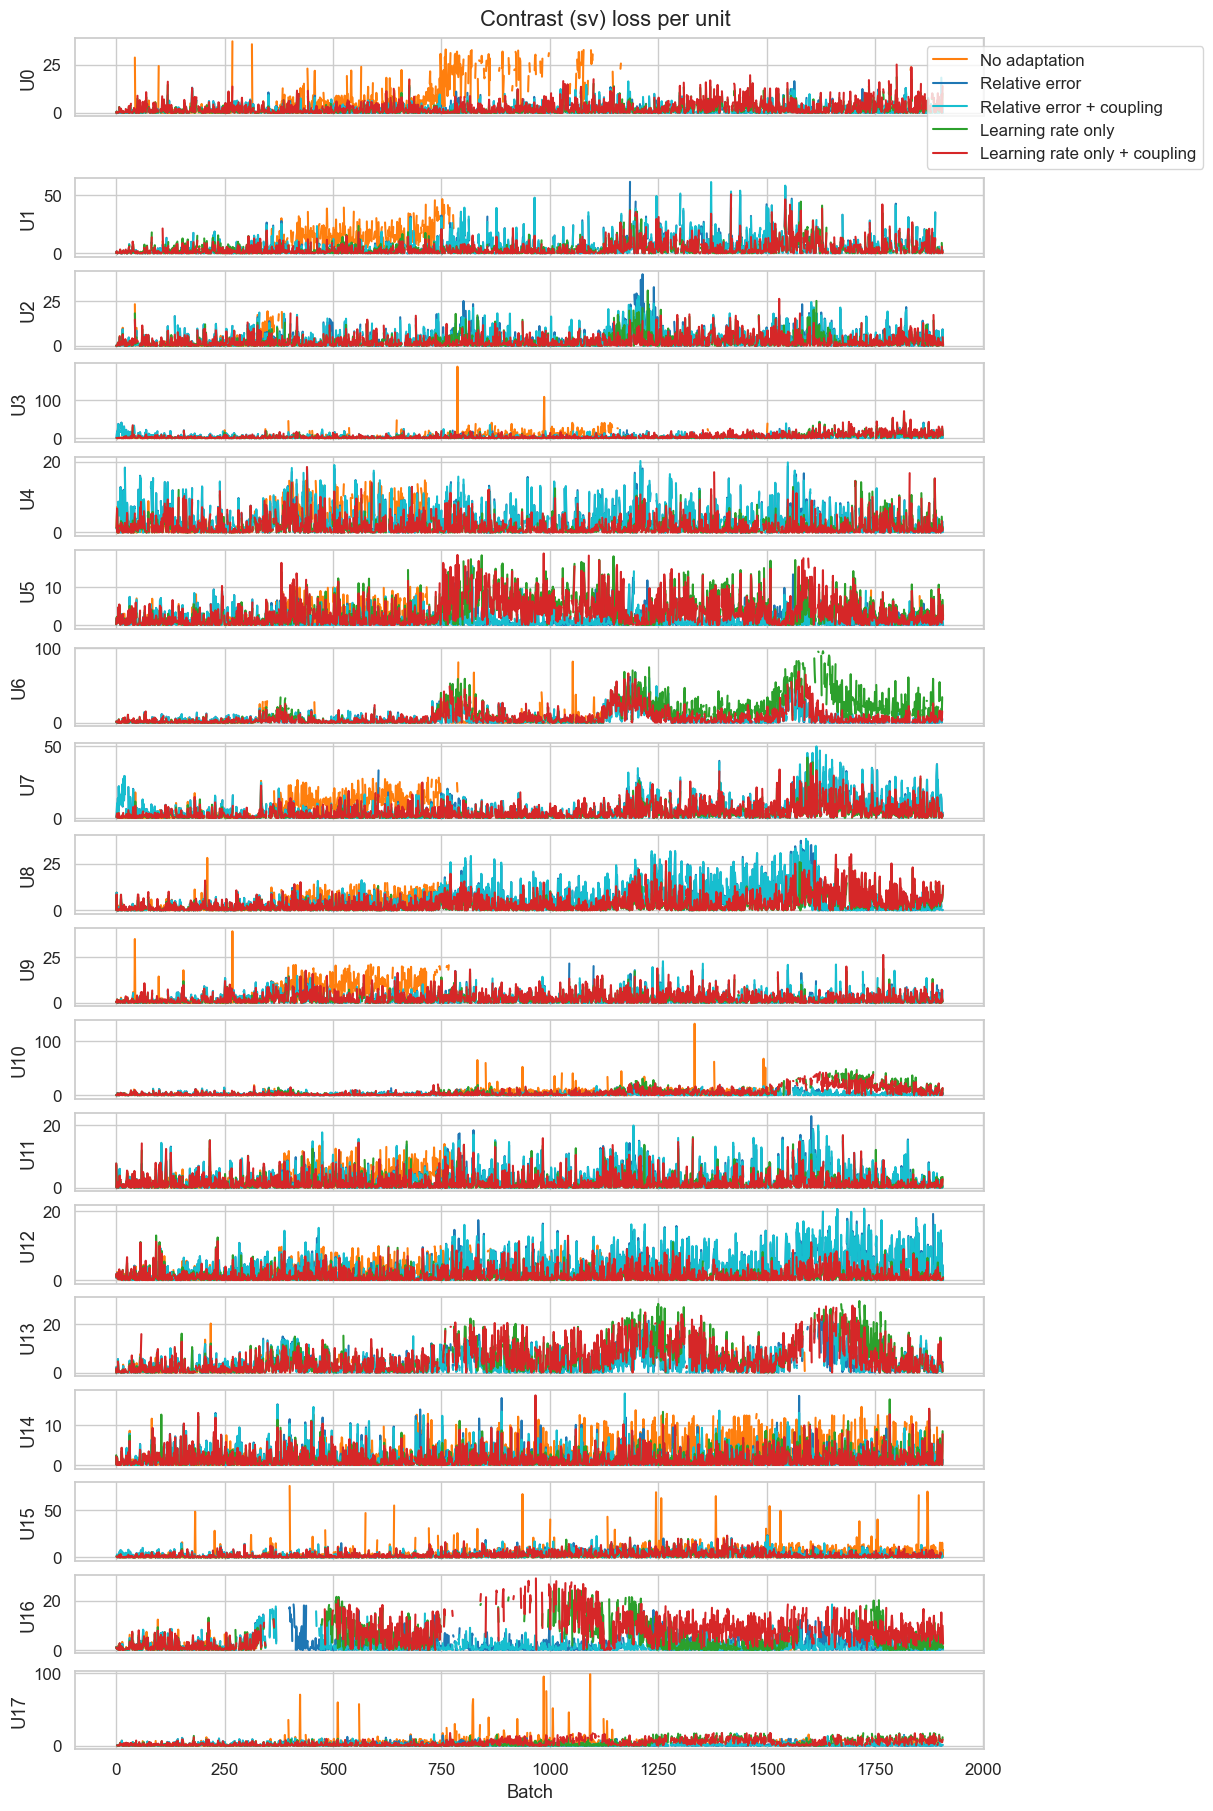

In [13]:
# Contrast (sv) loss per unit
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        axs[u].plot(cond_outputs[label]['sv_loss'][:, u], label=label, color=cond_colors[label])
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast (sv) loss per unit')
plt.show()


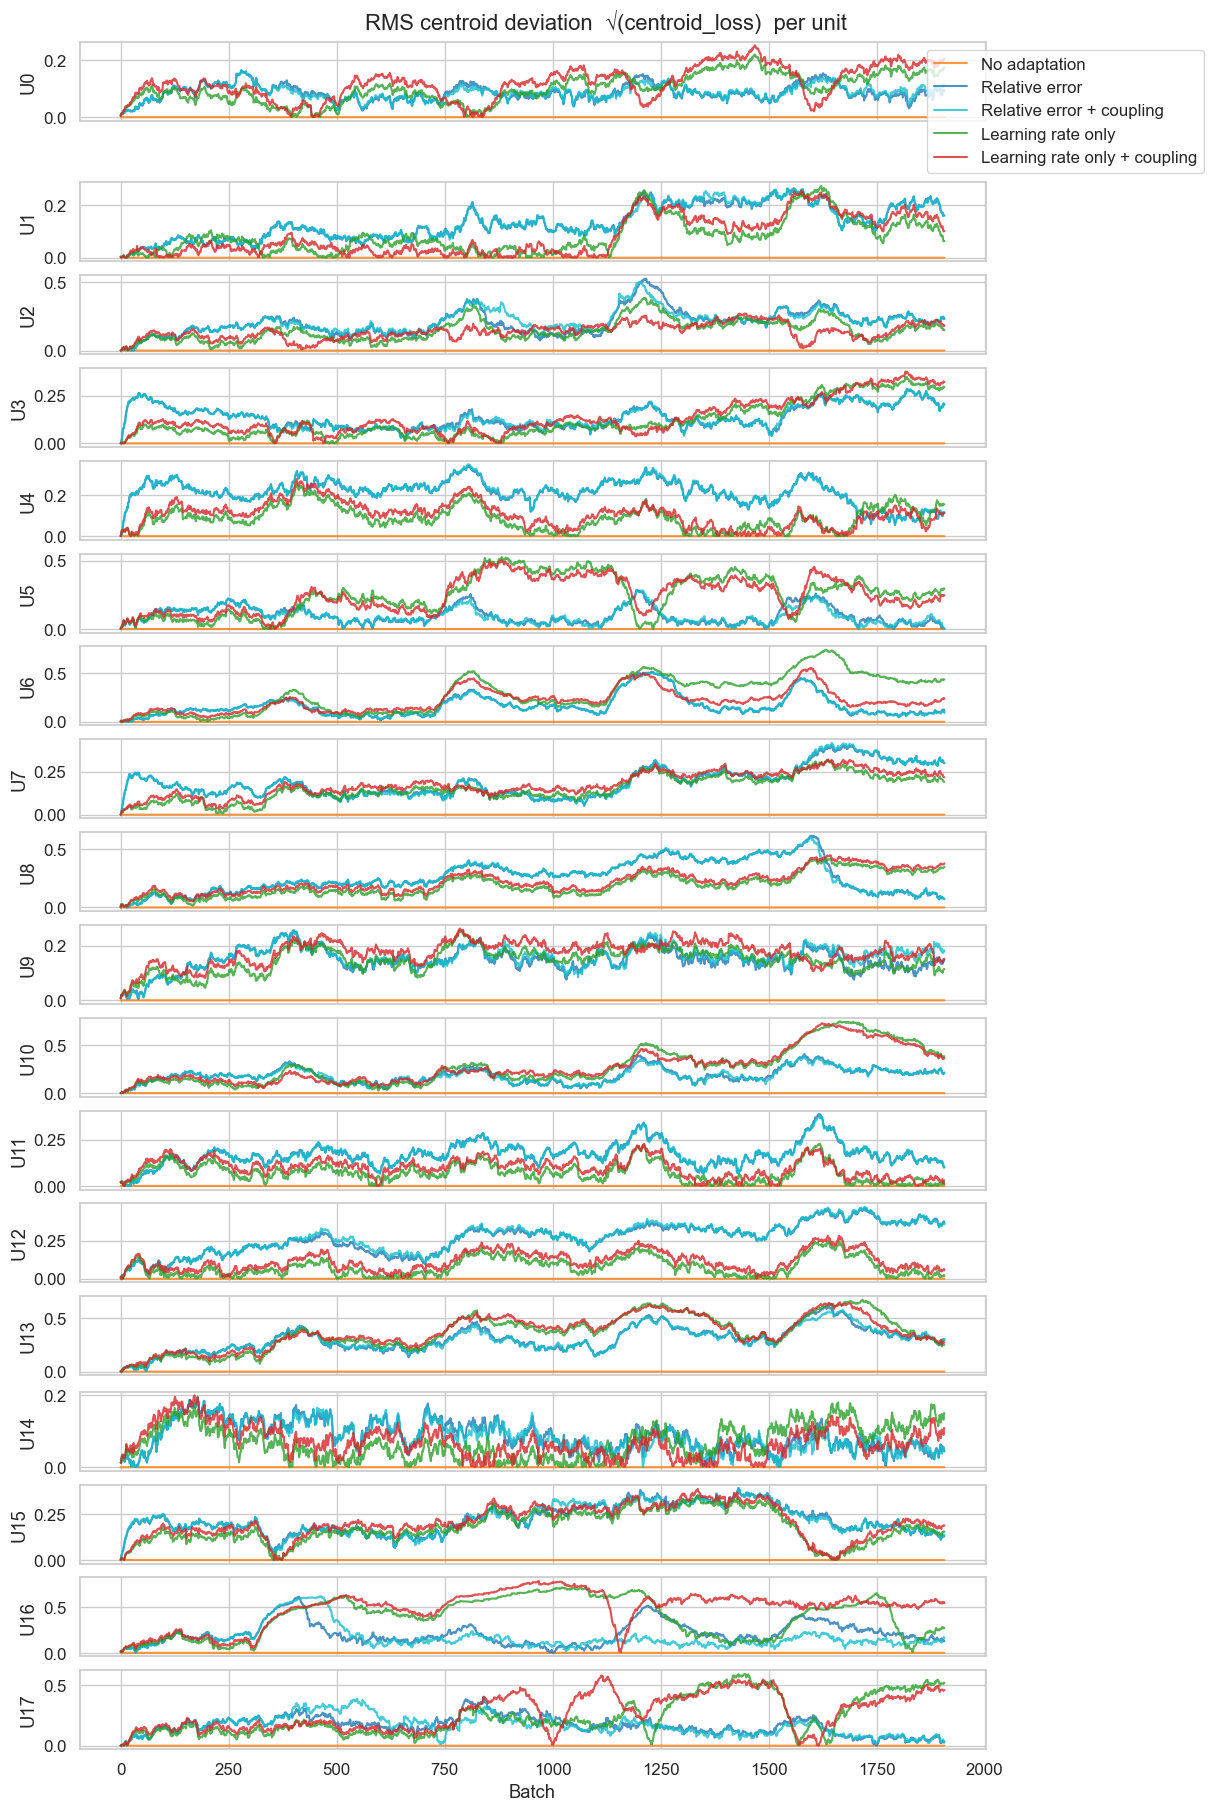

In [14]:
# RMS centroid deviation per unit
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        if 'centroid_loss' in out:
            axs[u].plot(
                np.sqrt(out['centroid_loss'][:, u].numpy()),
                label=label, color=cond_colors[label], alpha=0.8,
            )
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('RMS centroid deviation  √(centroid_loss)  per unit')
plt.show()


## 7. Clipping diagnostics

How often does the safety-net trust-region clip (`safety_clip_multiplier_{v,b} * lr_{v,b}`)
actually engage, versus the direction-normalized step being applied at its full,
unclipped size? Ratio = `‖Δ_applied‖ / ‖Δ_target‖`: 1.0 means the natural-gradient step
went through unchanged; below 1.0 means the clip capped it that batch. Requires
`cfg.debug=True` (set in the Relative-error / Learning-rate-only config cells above),
which records per-batch `delta_{V,B}_{raw_,}norm`. No-adaptation is excluded -- it never
takes a V/B step, so there's nothing to clip.


In [15]:
def _clip_ratios(diagnostics, n_units, tol=1e-6):
    """Per-batch ratio of applied delta-norm to pre-clip target norm.

    ratio == 1  -> step applied unchanged (clip inactive that batch)
    ratio <  1  -> the safety-net trust-region clip capped the step
    V is scalar (one whitening update per batch); B is per-unit ([n_units]).
    """
    idxs    = sorted(diagnostics.keys())
    v_ratio = np.full(len(idxs), np.nan)
    b_ratio = np.full((len(idxs), n_units), np.nan)
    for row, i in enumerate(idxs):
        d = diagnostics[i]
        if 'delta_V_raw_norm' in d and d['delta_V_raw_norm'] > tol:
            v_ratio[row] = d['delta_V_norm'] / d['delta_V_raw_norm']
        if 'delta_B_raw_norm' in d:
            raw, norm = d['delta_B_raw_norm'].numpy(), d['delta_B_norm'].numpy()
            valid = raw > tol
            b_ratio[row, valid] = norm[valid] / raw[valid]
    return np.array(idxs), v_ratio, b_ratio


clip_conditions = [
    'Relative error', 'Relative error + coupling',
    'Learning rate only', 'Learning rate only + coupling',
]
clip_diag = {}
for label in clip_conditions:
    batches, v_ratio, b_ratio = _clip_ratios(cond_outputs[label]['diagnostics'], n_units)
    clip_diag[label] = {'batches': batches, 'v_ratio': v_ratio, 'b_ratio': b_ratio}

    v_clipped_pct = np.nanmean(v_ratio < 1 - 1e-6) * 100
    b_clipped_pct = np.nanmean(b_ratio  < 1 - 1e-6) * 100
    print(f'{label:>30}: V clipped in {v_clipped_pct:5.1f}% of batches  |  '
          f'B clipped in {b_clipped_pct:5.1f}% of (batch, unit) pairs')


                Relative error: V clipped in   0.0% of batches  |  B clipped in   0.0% of (batch, unit) pairs
     Relative error + coupling: V clipped in   0.0% of batches  |  B clipped in   0.0% of (batch, unit) pairs
            Learning rate only: V clipped in   0.0% of batches  |  B clipped in  84.3% of (batch, unit) pairs
 Learning rate only + coupling: V clipped in   0.0% of batches  |  B clipped in  84.7% of (batch, unit) pairs


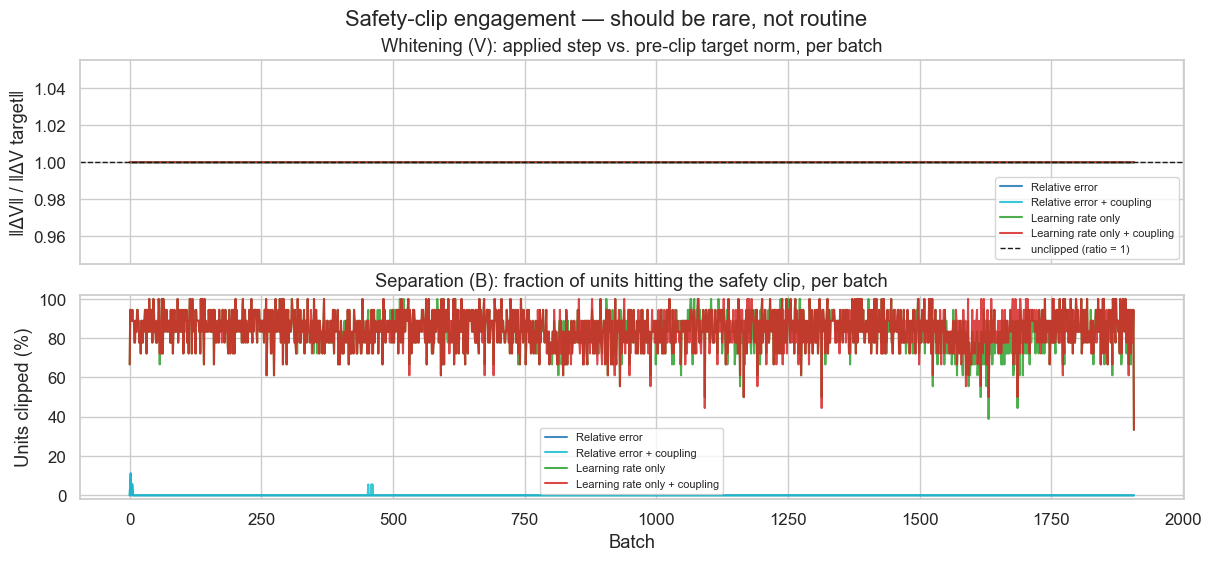

In [16]:
fig, (ax_v, ax_b) = plt.subplots(2, 1, figsize=(12, 5.5), layout='constrained', sharex=True)

for label in clip_conditions:
    cd = clip_diag[label]
    ax_v.plot(cd['batches'], cd['v_ratio'], label=label, color=cond_colors[label], alpha=0.85)
ax_v.axhline(1.0, color='k', linestyle='--', linewidth=1, label='unclipped (ratio = 1)')
ax_v.set(ylabel='‖ΔV‖ / ‖ΔV target‖',
         title='Whitening (V): applied step vs. pre-clip target norm, per batch')
ax_v.legend(fontsize=8, loc='lower right')

for label in clip_conditions:
    cd = clip_diag[label]
    frac_clipped = np.nanmean(cd['b_ratio'] < 1 - 1e-6, axis=1) * 100
    ax_b.plot(cd['batches'], frac_clipped, label=label, color=cond_colors[label], alpha=0.85)
ax_b.set(xlabel='Batch', ylabel='Units clipped (%)', ylim=(-2, 102),
         title='Separation (B): fraction of units hitting the safety clip, per batch')
ax_b.legend(fontsize=8)

plt.suptitle('Safety-clip engagement — should be rare, not routine')
plt.show()


## 8. IPTs and spike trains

Squared IPTs with detected spike times overlaid.

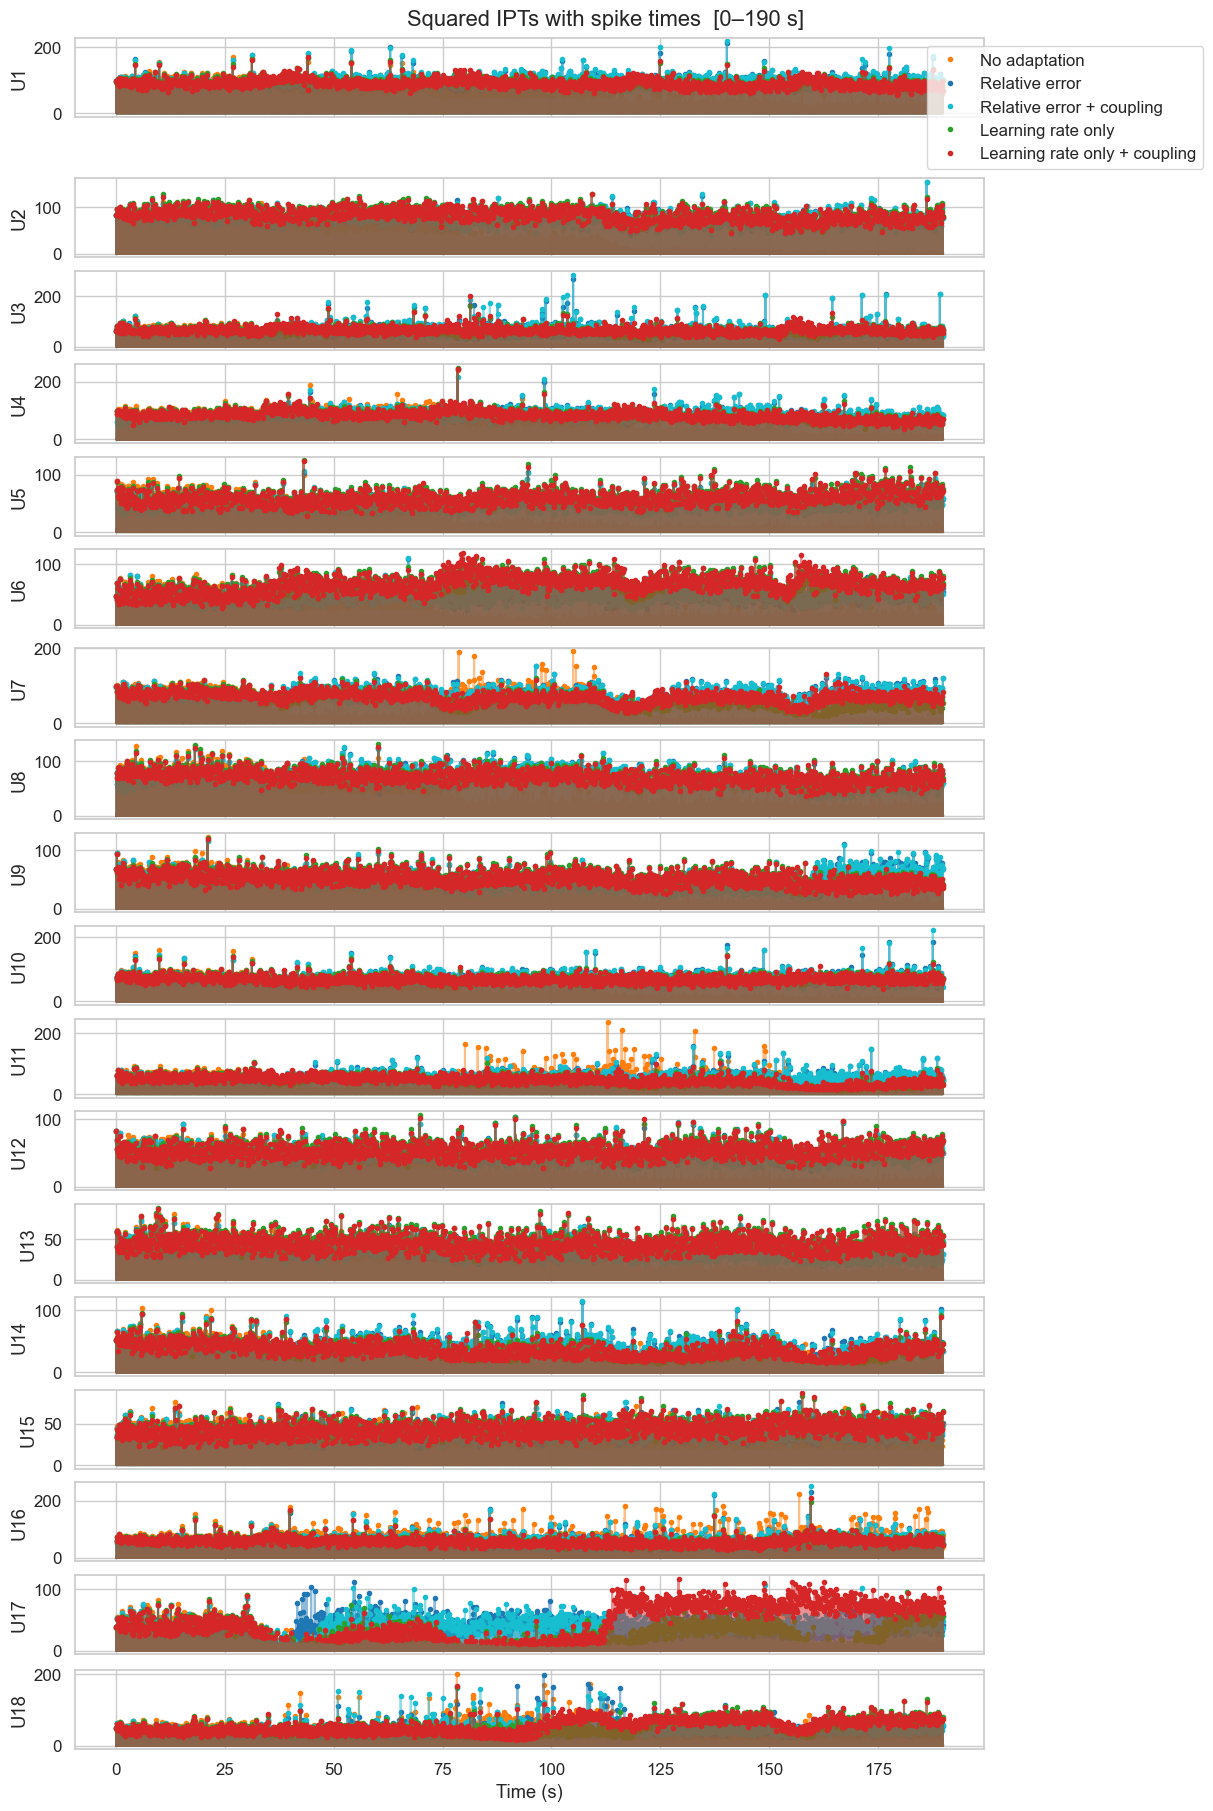

In [17]:
t0, t1 = 0, int(duration_s)
idxs   = np.arange(int(t0 * fs), int(t1 * fs))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out     = cond_outputs[label]
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(data['timestamps'][idxs], ipts_sq, color=cond_colors[label], alpha=0.5)
        smask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            data['timestamps'][idxs][smask], ipts_sq[smask],
            linestyle='None', marker='.', color=cond_colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'U{u + 1}')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Squared IPTs with spike times  [{t0}–{t1} s]')
plt.show()


## 9. Decomposition quality metrics

A unit is **good** if SIL ≥ 0.9, DR ∈ [5, 35] pps, CoV ≤ 35%, PNR ≥ 30 dB.

In [18]:
rows = []
for label in cond_labels:
    out       = cond_outputs[label]
    spikes_np = out['spikes'].numpy().astype(float)
    ipts_np   = out['ipts'].numpy()

    sil  = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr  = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr   = get_discharge_rate(spikes_np, timestamps, discard_isi=None)
    cov  = get_coefficient_of_variation(spikes_np, timestamps, discard_isi=None)
    good = find_reliable_units(dr, cov, sil, pnr,
                               dr_low_thr=5, dr_upp_thr=35, cov_thr=0.35,
                               sil_thr=0.9, pnr_thr=30)
    for u in range(spikes_np.shape[1]):
        rows.append({'unit': u, 'condition': label, 'good': bool(good[u]),
                     'SIL': sil[u], 'PNR (dB)': pnr[u], 'DR (pps)': dr[u], 'CoV (%)': cov[u]})

df_all  = pd.DataFrame(rows)
n_total = df_all['unit'].nunique()

print(df_all.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']]
      .agg(['median', 'mean']).round(2))
print()
for cond, grp in df_all.groupby('condition'):
    print(f'{cond}: {grp["good"].sum()} / {n_total} good units')


                                 SIL       PNR (dB)        DR (pps)        \
                              median  mean   median   mean   median  mean   
condition                                                                   
Learning rate only              0.96  0.95    35.63  36.03     9.09  9.11   
Learning rate only + coupling   0.96  0.94    35.09  35.86     9.09  9.20   
No adaptation                   0.94  0.93    31.78  32.16     5.41  5.91   
Relative error                  0.95  0.95    33.73  34.18     9.39  9.78   
Relative error + coupling       0.95  0.95    33.49  33.94     9.37  9.73   

                              CoV (%)        
                               median  mean  
condition                                    
Learning rate only               0.22  0.33  
Learning rate only + coupling    0.22  0.29  
No adaptation                    3.17  3.21  
Relative error                   0.23  0.29  
Relative error + coupling        0.23  0.33  

Learning rate 

C:\Users\Irene\AppData\Local\Temp\ipykernel_24396\1266819189.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_24396\1266819189.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_24396\1266819189.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\I

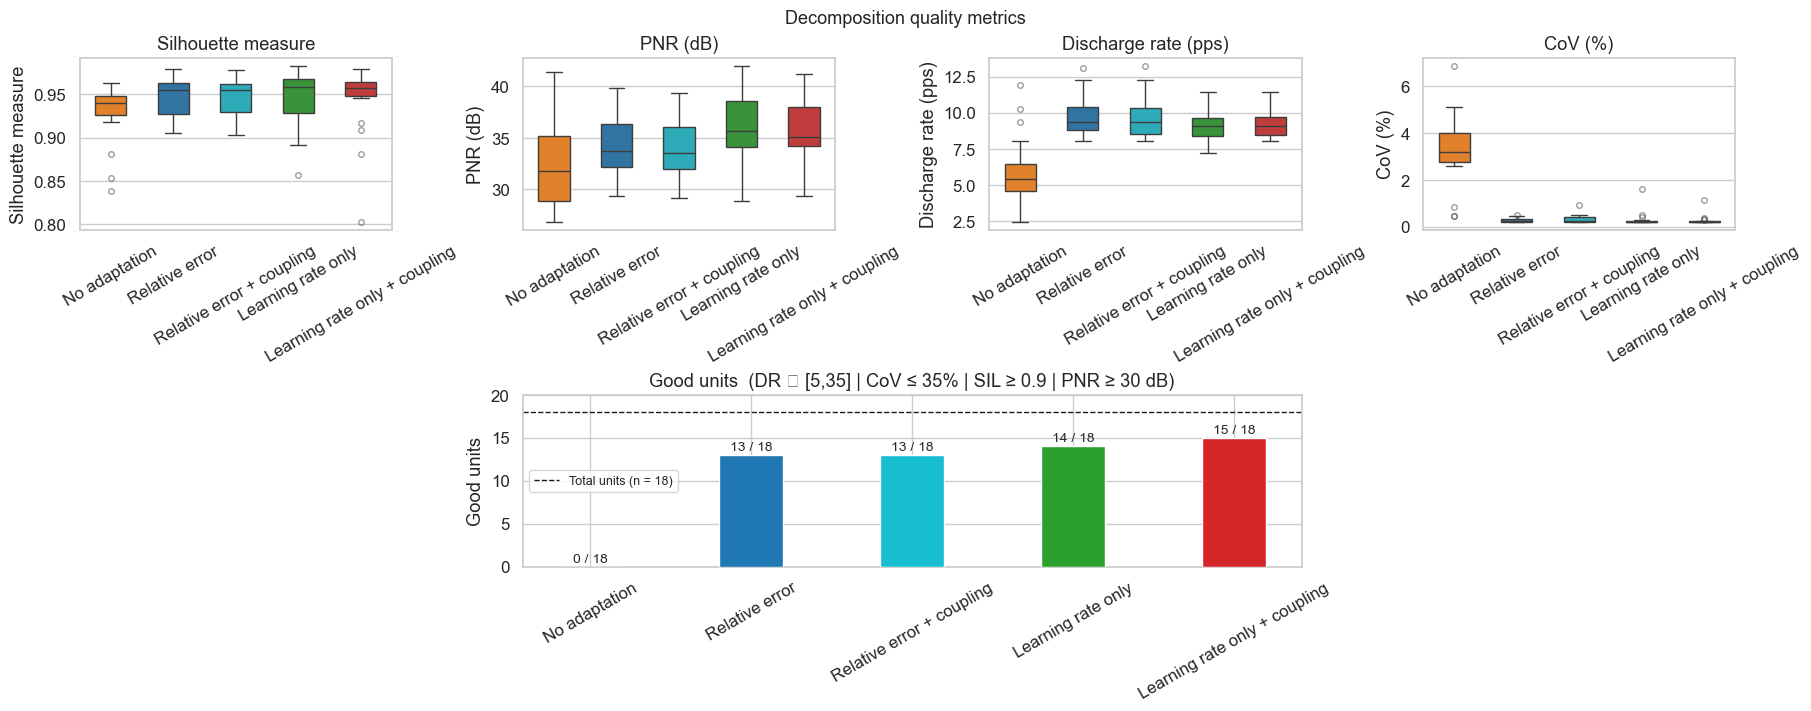

In [19]:
order   = cond_labels
palette = cond_colors

df_all['condition'] = pd.Categorical(df_all['condition'], categories=order, ordered=True)

fig = plt.figure(figsize=(18, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)
ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])

for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=30)

good_counts = df_all.groupby('condition', observed=True)['good'].sum().reindex(order)
bars = ax_bar.bar(order, good_counts.values,
                  color=[palette[c] for c in order], width=0.4, zorder=3)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(ylabel='Good units', ylim=(0, n_total + 2),
           title='Good units  (DR ∈ [5,35] | CoV ≤ 35% | SIL ≥ 0.9 | PNR ≥ 30 dB)')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=30)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, count + 0.2,
                f'{int(count)} / {n_total}', ha='center', va='bottom', fontsize=10)
plt.suptitle('Decomposition quality metrics', fontsize=13)
plt.show()


## 10. Rate of agreement with ground truth

Ground truth spike trains (`spikes_gt`) are available in the simulated dataset.  Unit matching is performed on the calibration segment (first 30 s) using the no-adaptation pairing as the common reference.

In [20]:
cal_idx = np.arange(0, int(30 * fs))

roa_cal = {}
pair_no = None
for label in cond_labels:
    roa, pair, _ = rate_of_agreement(
        data['spikes_gt'].numpy()[cal_idx],
        cond_outputs[label]['spikes'].numpy()[cal_idx],
        fs=fs,
    )
    roa_cal[label] = roa
    if label == 'No adaptation':
        pair_no = pair

for label in cond_labels:
    roa = roa_cal[label]
    print(f'RoA calibration | {label:<30}: {roa.mean()*100:.2f} ± {roa.std()*100:.2f}%')

# Use no-adapt pairing as common reference
pair_arr   = np.array(pair_no)
sim_spikes = data['spikes_gt'].numpy()[:, pair_arr[:, 0]]


RoA calibration | No adaptation                 : 99.40 ± 0.49%
RoA calibration | Relative error                : 99.27 ± 0.55%
RoA calibration | Relative error + coupling     : 99.27 ± 0.55%
RoA calibration | Learning rate only            : 99.33 ± 0.50%
RoA calibration | Learning rate only + coupling : 99.24 ± 0.54%


RoA full | No adaptation                 : 37.88 ± 18.23%  (med: 37.29%)
RoA full | Relative error                : 85.11 ± 24.33%  (med: 98.71%)
RoA full | Relative error + coupling     : 83.99 ± 26.08%  (med: 98.32%)
RoA full | Learning rate only            : 89.97 ± 22.03%  (med: 99.23%)
RoA full | Learning rate only + coupling : 89.20 ± 23.72%  (med: 99.12%)


c:\Users\Irene\anaconda3\envs\adapt_decomp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


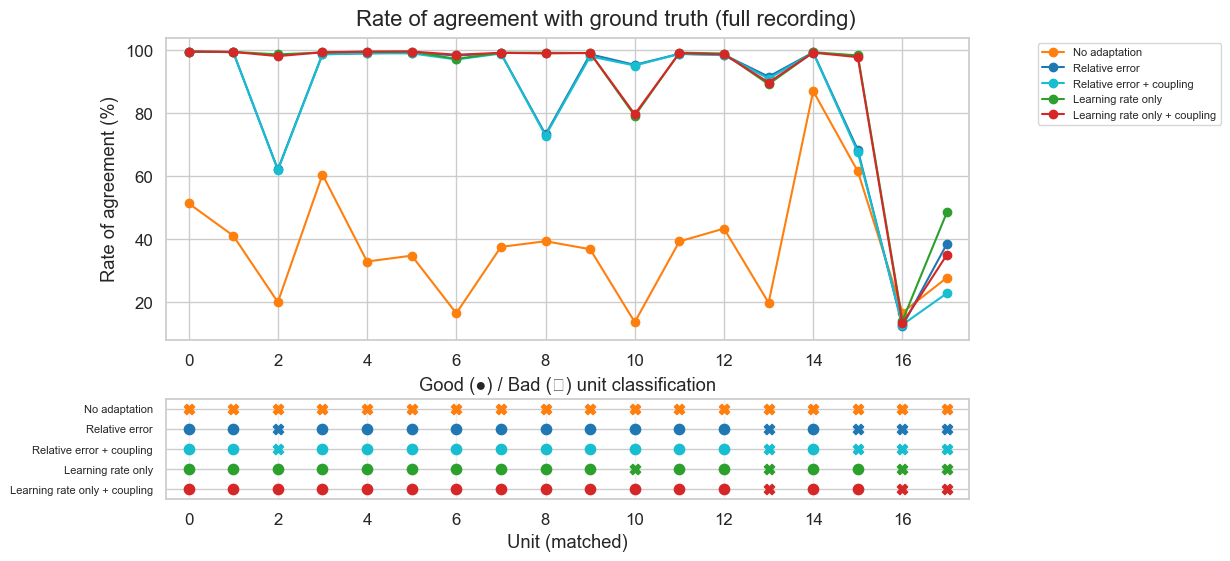

In [21]:
roa_full = {
    label: rate_of_agreement_paired(
        sim_spikes, cond_outputs[label]['spikes'].numpy(), fs=fs, tol_spike_ms=2
    )[0]
    for label in cond_labels
}

unit_ids = pair_arr[:, 1]
n_pairs  = len(unit_ids)
x        = np.arange(n_pairs)

for label in cond_labels:
    roa = roa_full[label]
    print(f'RoA full | {label:<30}: {roa.mean()*100:.2f} ± {roa.std()*100:.2f}%  '
          f'(med: {np.median(roa)*100:.2f}%)')

good_lookup = {
    label: df_all[df_all['condition'] == label].set_index('unit')['good']
    for label in cond_labels
}

fig, (ax_roa, ax_good) = plt.subplots(
    2, 1, figsize=(12, 5.5), layout='constrained',
    gridspec_kw={'height_ratios': [3, 1]},
)
for label in cond_labels:
    ax_roa.plot(x, roa_full[label] * 100, marker='o', label=label, color=cond_colors[label])
ax_roa.set(ylabel='Rate of agreement (%)', xlim=(-0.5, n_pairs - 0.5))
ax_roa.legend(loc='upper right', bbox_to_anchor=(1.32, 1), fontsize=8)

y_pos = {label: len(cond_labels) - 1 - i for i, label in enumerate(cond_labels)}
for label in cond_labels:
    for i, uid in enumerate(unit_ids):
        is_good = bool(good_lookup[label].get(uid, False))
        ax_good.scatter(i, y_pos[label],
                        color=cond_colors[label],
                        marker='o' if is_good else 'X',
                        s=55, zorder=3)

ax_good.set_yticks(list(y_pos.values()))
ax_good.set_yticklabels(list(y_pos.keys()), fontsize=8)
ax_good.set(xlabel='Unit (matched)', xlim=(-0.5, n_pairs - 0.5),
            title='Good (●) / Bad (✗) unit classification',
            ylim=(-0.5, len(y_pos) - 0.5))
ax_good.grid(axis='x', alpha=0.3)
plt.suptitle('Rate of agreement with ground truth (full recording)')
plt.show()


In [22]:
# Save per-unit RoA for the comparison notebook
_key = {
    'No adaptation':                 'no',
    'Relative error':                're',
    'Relative error + coupling':     're_c',
    'Learning rate only':            'lo',
    'Learning rate only + coupling': 'lo_c',
}
roa_summary = {'unit_ids': unit_ids.tolist()}
for label in cond_labels:
    roa_summary[f'roa_{_key[label]}'] = roa_full[label].tolist()

with open(RESULTS_DIR / 'roa_summary.json', 'w') as f:
    json.dump(roa_summary, f, indent=2)

# Save quality metrics DataFrame
df_all.to_csv(RESULTS_DIR / 'quality_metrics.csv', index=False)
print(f'Saved RoA summary and quality metrics → {RESULTS_DIR}')


Saved RoA summary and quality metrics → ..\data\example\opt_results\kl_to_cal_lr_fixed


## 11. Coupling effect summary

Isolates the effect of `wh_b_coupling` under each update rule by comparing each
condition directly against its coupling-enabled counterpart.


In [23]:
pairs = [
    ('Relative error', 'Relative error + coupling'),
    ('Learning rate only', 'Learning rate only + coupling'),
]

summary_rows = []
for base, coupled in pairs:
    good_base    = int(df_all[df_all['condition'] == base]['good'].sum())
    good_coupled = int(df_all[df_all['condition'] == coupled]['good'].sum())
    summary_rows.append({
        'lr_alone':                   base == 'Learning rate only',
        'condition':                  base,
        'good units (no coupling)':   good_base,
        'good units (coupling)':      good_coupled,
        'Δ good units':               good_coupled - good_base,
        'RoA full % (no coupling)':   roa_full[base].mean() * 100,
        'RoA full % (coupling)':      roa_full[coupled].mean() * 100,
        'Δ RoA full (pp)':            (roa_full[coupled].mean() - roa_full[base].mean()) * 100,
    })

summary_df = pd.DataFrame(summary_rows).round(2)
summary_df


,lr_alone,condition,good units (no coupling),good units (coupling),Δ good units,RoA full % (no coupling),RoA full % (coupling),Δ RoA full (pp)
0,False,Relative error,13,13,0,85.11,83.99,-1.12
1,True,Learning rate only,14,15,1,89.97,89.20,-0.77
